In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('cumulative_2026.06.21_12.57.11.csv', comment='#')
df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_vet_stat,koi_vet_date,koi_pdisposition,koi_score,koi_fpflag_nt,...,koi_dicco_mdec,koi_dicco_mdec_err,koi_dicco_msky,koi_dicco_msky_err,koi_dikco_mra,koi_dikco_mra_err,koi_dikco_mdec,koi_dikco_mdec_err,koi_dikco_msky,koi_dikco_msky_err
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,0.200,0.160,0.200,0.170,0.080,0.130,0.310,0.170,0.320,0.160
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,Done,2018-08-16,CANDIDATE,0.969,0,...,0.000,0.480,0.390,0.360,0.490,0.340,0.120,0.730,0.500,0.450
2,3,10811496,K00753.01,NaN,CANDIDATE,Done,2018-08-16,CANDIDATE,0.000,0,...,-0.034,0.070,0.042,0.072,0.002,0.071,-0.027,0.074,0.027,0.074
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,Done,2018-08-16,FALSE POSITIVE,0.000,0,...,0.147,0.078,0.289,0.079,-0.257,0.072,0.099,0.077,0.276,0.076
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,Done,2018-08-16,CANDIDATE,1.000,0,...,-0.090,0.180,0.100,0.140,0.070,0.180,0.020,0.160,0.070,0.200


In [ ]:
for col in df.columns:
    print(col)

rowid
kepid
kepoi_name
kepler_name
koi_disposition
koi_vet_stat
koi_vet_date
koi_pdisposition
koi_score
koi_fpflag_nt
koi_fpflag_ss
koi_fpflag_co
koi_fpflag_ec
koi_disp_prov
koi_comment
koi_period
koi_period_err1
koi_period_err2
koi_time0bk
koi_time0bk_err1
koi_time0bk_err2
koi_time0
koi_time0_err1
koi_time0_err2
koi_eccen
koi_eccen_err1
koi_eccen_err2
koi_longp
koi_longp_err1
koi_longp_err2
koi_impact
koi_impact_err1
koi_impact_err2
koi_duration
koi_duration_err1
koi_duration_err2
koi_ingress
koi_ingress_err1
koi_ingress_err2
koi_depth
koi_depth_err1
koi_depth_err2
koi_ror
koi_ror_err1
koi_ror_err2
koi_srho
koi_srho_err1
koi_srho_err2
koi_fittype
koi_prad
koi_prad_err1
koi_prad_err2
koi_sma
koi_sma_err1
koi_sma_err2
koi_incl
koi_incl_err1
koi_incl_err2
koi_teq
koi_teq_err1
koi_teq_err2
koi_insol
koi_insol_err1
koi_insol_err2
koi_dor
koi_dor_err1
koi_dor_err2
koi_limbdark_mod
koi_ldm_coeff4
koi_ldm_coeff3
koi_ldm_coeff2
koi_ldm_coeff1
koi_parm_prov
koi_max_sngle_ev
koi_max_mult_ev
koi_

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Columns: 141 entries, rowid to koi_dikco_msky_err
dtypes: float64(117), int64(7), object(17)
memory usage: 10.3+ MB


In [ ]:
df.shape

(9564, 141)

**About dataset-"cumulative_2026.06.21_12.57.11.csv"**

this is a dataset of NASA space exoloration exoplanet dataset.

**Column descriptions**



*  **IDENTIFIER/DIPOSITION**





1.   `kepid:`Kepler ID,unique id for the star target in the kepler input katalog.


2.   `kepoi_name:` KOI name,unique name for the kepler object of interest.


1.   `koi_diposition:`exoplanet archive diposition(FALSE POSITIVE,CONFIRMED,CANDIDATE)
2.   `koi_pdiposition:` diposition using kepler data(internal assessment).

1.  ` kepler_name:` kepler name-eg-kepler 22b, for confirmed/validated exoplanets.
2.   `koi score:`disposition score(0-1)-higher value indicates higher confidence in planet candidate.





* **  False Positive Flags **(koi_fpflag_*)-binary flags(1,0) indication why an objwect is flagged as false positive.


1.   `koi_fpflag_nt:` Not Transit-like - Signal does not look like a planet transit.
2.   `koi_fpflag_ss:` Stellar Eclipse - Signal is a stellar eclipsing binary.


1.   `koi_fpflag_co:` Centroid Offset - Source of transit is not on the target star.
2.   `koi_fpflag_ec:` Ephemeris Match - Signal matches a known contaminated star.






*  ** Stellar & Positional Parameters:**



1.   `koi_steff / err1/err2: `Stellar Effective Temperature (Kelvin) and its upper/lower errors.

1.   `koi_slogg / err1/err2: `Stellar Surface Gravity (
) and its upper/lower errors.
2.   koi_srad / err1/err2: Stellar Radius (Solar radii) and its upper/lower errors.


2.   `ra / dec:` Right Ascension and Declination of the target.

1.   `koi_kepmag:` Kepler-band magnitude - Brightness of the star in Kepler’s field













**1.ID / Naming Columns:**


`kepid` → Kepler star ID number

`kepoi_name` → Kepler Object of Interest name

`kepler_name` → Official confirmed planet name

`koi_tce_delivname` → Pipeline internal name

 These are labels, not predictive features, we Drop these for modeling.


**2.Target / Classification Columns:**

`koi_disposition` → Final status (CONFIRMED / FALSE POSITIVE / CANDIDATE)

`koi_pdisposition `→ Disposition using Kepler data only

`koi_score` → Probability score from NASA pipeline
we drop koi_score to prevent data leakage into the model.

-data leakage-model having aritifical accuracy due to learning from probability statictics given in the data.



 **3.False Positive Flags**

`koi_fpflag_nt` → Not transit-like

`koi_fpflag_ss `→ Stellar eclipse false positive

`koi_fpflag_co` → Centroid offset contamination

`koi_fpflag_ec` → Ephemeris contamination

These are NASA’s internal diagnostic flags.can again cause data leakage.


**4.Orbital Features (Important)**

These describe planet orbit behavior.

`koi_period` → How long planet takes to orbit star (days)

`koi_time0bk` → Transit timing reference

`koi_impact` → How centrally it passes in front of star

`koi_duration `→ Transit duration (hours)

`koi_depth` → Transit depth (brightness drop)

`koi_model_snr` → Signal-to-noise ratio

These are very important for classification.
Real planets have specific transit patterns.

**5.Planet Physical Properties**


koi_prad → Planet radius (Earth radii)

koi_teq → Equilibrium temperature (Kelvin)

koi_insol → Insolation (energy received)

**6.Stellar Features (Host Star Properties)**

`koi_steff`→ Star temperature

`koi_slogg `→ Star surface gravity

`koi_srad `→ Star radius

**7.Uncertainty Columns (_err1, _err2)**

Example:

```
# koi_period_err1

koi_prad_err2

```
etc.

**8.Sky Coordinates**

ra → Right ascension

dec → Declination

koi_kepmag → Brightness magnitude

Coordinates usually not predictive of planet existence.
Magnitude may influence detection quality.


In [ ]:
exo=df.copy()

In [ ]:
cols_to_drop = [
    'kepid', 'kepoi_name', 'kepler_name', 'koi_tce_delivname', 'koi_score',
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
    'koi_period_err1', 'koi_prad_err2', 'koi_prad_err1', 'koi_period_err2',
    'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact_err1', 'koi_impact_err2',
    'koi_duration_err1', 'koi_duration_err2', 'koi_depth_err1', 'koi_depth_err2',
    'koi_teq_err1', 'koi_teq_err2', 'koi_insol_err1', 'koi_insol_err2',
    'koi_steff_err1', 'koi_steff_err2', 'koi_slogg_err1', 'koi_slogg_err2',
    'koi_srad_err1', 'koi_srad_err2','rowid','koi_vet_date','koi_pdisposition','koi_disp_prov','koi_comment','koi_fittype','koi_parm_prov'
,'koi_sparprov',
'koi_datalink_dvr',
'koi_datalink_dvs','ra',
'dec','koi_gmag',
'koi_rmag',
'koi_imag',
'koi_zmag',
'koi_jmag',
'koi_hmag',
'koi_kmag','koi_time0_err1', 'koi_time0_err2',
'koi_eccen_err1',
'koi_eccen_err2',
'koi_longp_err1',
'koi_longp_err2',
'koi_ingress_err1',
'koi_ingress_err2',
'koi_ror_err1',
'koi_ror_err2',
'koi_srho_err1',
'koi_srho_err2',
'koi_sma_err1',
'koi_sma_err2',
'koi_incl_err1',
'koi_incl_err2',
'koi_dor_err1',
'koi_dor_err2',
'koi_smet_err1',
'koi_smet_err2',
'koi_smass_err1',
'koi_smass_err2',
'koi_sage_err1',
'koi_sage_err2',
'koi_fwm_sra_err',
'koi_fwm_sdec_err',
'koi_fwm_srao_err',
'koi_fwm_sdeco_err',
'koi_fwm_prao_err',
'koi_fwm_pdeco_err',
'koi_dicco_mra_err',
'koi_dicco_mdec_err',
'koi_dicco_msky_err',
'koi_dikco_mra_err',
'koi_dikco_mdec_err',
'koi_dikco_msky_err','koi_limbdark_mod', 'koi_quarters', 'koi_trans_mod','koi_vet_stat'
]

exo.drop(cols_to_drop, axis=1, inplace=True,errors='ignore')
exo.head()

,koi_disposition,koi_period,koi_time0bk,koi_time0,koi_eccen,koi_longp,koi_impact,koi_duration,koi_ingress,koi_depth,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,CONFIRMED,9.488036,170.538750,2455003.539,0.0,NaN,0.146,2.95750,NaN,615.8,...,0.430,0.940,-0.00020,-0.00055,-0.010,0.200,0.200,0.080,0.310,0.320
1,CONFIRMED,54.418383,162.513840,2454995.514,0.0,NaN,0.586,4.50700,NaN,874.8,...,-0.630,1.230,0.00066,-0.00105,0.390,0.000,0.390,0.490,0.120,0.500
2,CANDIDATE,19.899140,175.850252,2455008.850,0.0,NaN,0.969,1.78220,NaN,10829.0,...,-0.021,-0.038,0.00070,0.00060,-0.025,-0.034,0.042,0.002,-0.027,0.027
3,FALSE POSITIVE,1.736952,170.307565,2455003.308,0.0,NaN,1.276,2.40641,NaN,8079.2,...,-0.111,0.002,0.00302,-0.00142,-0.249,0.147,0.289,-0.257,0.099,0.276
4,CONFIRMED,2.525592,171.595550,2455004.596,0.0,NaN,0.701,1.65450,NaN,603.3,...,-0.010,0.230,0.00008,-0.00007,0.030,-0.090,0.100,0.070,0.020,0.070


In [ ]:
exo

,koi_disposition,koi_period,koi_time0bk,koi_time0,koi_eccen,koi_longp,koi_impact,koi_duration,koi_ingress,koi_depth,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,CONFIRMED,9.488036,170.538750,2455003.539,0.0,NaN,0.146,2.95750,NaN,615.8,...,0.430,0.940,-0.000200,-0.000550,-0.010,0.200,0.200,0.080,0.310,0.320
1,CONFIRMED,54.418383,162.513840,2454995.514,0.0,NaN,0.586,4.50700,NaN,874.8,...,-0.630,1.230,0.000660,-0.001050,0.390,0.000,0.390,0.490,0.120,0.500
2,CANDIDATE,19.899140,175.850252,2455008.850,0.0,NaN,0.969,1.78220,NaN,10829.0,...,-0.021,-0.038,0.000700,0.000600,-0.025,-0.034,0.042,0.002,-0.027,0.027
3,FALSE POSITIVE,1.736952,170.307565,2455003.308,0.0,NaN,1.276,2.40641,NaN,8079.2,...,-0.111,0.002,0.003020,-0.001420,-0.249,0.147,0.289,-0.257,0.099,0.276
4,CONFIRMED,2.525592,171.595550,2455004.596,0.0,NaN,0.701,1.65450,NaN,603.3,...,-0.010,0.230,0.000080,-0.000070,0.030,-0.090,0.100,0.070,0.020,0.070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,FALSE POSITIVE,0.527699,131.705093,2454964.705,0.0,NaN,1.252,3.22210,NaN,1579.2,...,0.792,-0.484,-0.000237,0.000178,2.132,-1.757,2.763,2.344,-1.756,2.929
9560,CANDIDATE,1.739849,133.001270,2454966.001,0.0,NaN,0.043,3.11400,NaN,48.5,...,0.100,2.000,-0.000018,-0.000074,0.740,-0.250,0.780,0.500,-0.180,0.530
9561,FALSE POSITIVE,0.681402,132.181750,2454965.182,0.0,NaN,0.147,0.86500,NaN,103.6,...,7.200,-5.600,-0.000720,0.000500,3.410,-3.650,5.000,3.380,-3.890,5.160
9562,CANDIDATE,333.486169,153.615010,2454986.615,0.0,NaN,0.214,3.19900,NaN,639.1,...,0.310,0.010,-0.000290,-0.000100,1.061,1.320,1.690,1.450,1.370,2.000


In [ ]:
exo.shape

(9564, 51)

In [ ]:
for col in exo.columns:
    print(col)

koi_disposition
koi_period
koi_time0bk
koi_time0
koi_eccen
koi_longp
koi_impact
koi_duration
koi_ingress
koi_depth
koi_ror
koi_srho
koi_prad
koi_sma
koi_incl
koi_teq
koi_insol
koi_dor
koi_ldm_coeff4
koi_ldm_coeff3
koi_ldm_coeff2
koi_ldm_coeff1
koi_max_sngle_ev
koi_max_mult_ev
koi_model_snr
koi_count
koi_num_transits
koi_tce_plnt_num
koi_bin_oedp_sig
koi_model_dof
koi_model_chisq
koi_steff
koi_slogg
koi_smet
koi_srad
koi_smass
koi_sage
koi_kepmag
koi_fwm_stat_sig
koi_fwm_sra
koi_fwm_sdec
koi_fwm_srao
koi_fwm_sdeco
koi_fwm_prao
koi_fwm_pdeco
koi_dicco_mra
koi_dicco_mdec
koi_dicco_msky
koi_dikco_mra
koi_dikco_mdec
koi_dikco_msky


In [ ]:
exo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 51 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   koi_disposition   9564 non-null   object 
 1   koi_period        9564 non-null   float64
 2   koi_time0bk       9564 non-null   float64
 3   koi_time0         9564 non-null   float64
 4   koi_eccen         9201 non-null   float64
 5   koi_longp         0 non-null      float64
 6   koi_impact        9201 non-null   float64
 7   koi_duration      9564 non-null   float64
 8   koi_ingress       0 non-null      float64
 9   koi_depth         9201 non-null   float64
 10  koi_ror           9201 non-null   float64
 11  koi_srho          9243 non-null   float64
 12  koi_prad          9201 non-null   float64
 13  koi_sma           9201 non-null   float64
 14  koi_incl          9200 non-null   float64
 15  koi_teq           9201 non-null   float64
 16  koi_insol         9243 non-null   float64


In [ ]:
exo[exo['koi_disposition'].isnull()]

,koi_disposition,koi_period,koi_time0bk,koi_time0,koi_eccen,koi_longp,koi_impact,koi_duration,koi_ingress,koi_depth,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky


In [ ]:
exo[exo['koi_impact'].isnull()]

,koi_disposition,koi_period,koi_time0bk,koi_time0,koi_eccen,koi_longp,koi_impact,koi_duration,koi_ingress,koi_depth,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
330,FALSE POSITIVE,0.734525,133.431080,2454966.431,NaN,NaN,NaN,6.70,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
360,FALSE POSITIVE,6.721078,134.777598,2454967.778,NaN,NaN,NaN,7.46,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
479,CANDIDATE,1.008617,132.109479,2454965.109,NaN,NaN,NaN,0.91,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
493,FALSE POSITIVE,200.611033,456.844440,2455289.844,NaN,NaN,NaN,7.13,NaN,NaN,...,13.74,17.19,-0.037300,-0.046600,3.580,4.202,5.520,3.676,4.350,5.70
495,FALSE POSITIVE,1.634846,134.512115,2454967.512,NaN,NaN,NaN,6.11,NaN,NaN,...,337.00,-26.40,NaN,0.000331,11.279,-3.154,11.712,10.991,-3.208,11.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9348,CANDIDATE,1.126260,132.296346,2454965.296,NaN,NaN,NaN,3.62,NaN,NaN,...,-1.61,0.96,0.000240,-0.000142,0.340,0.410,0.530,0.204,0.410,0.46
9393,CANDIDATE,0.587300,132.350233,2454965.350,NaN,NaN,NaN,0.82,NaN,NaN,...,0.60,-2.20,0.000032,0.000078,-0.290,-0.940,0.990,-0.390,-0.960,1.04
9406,FALSE POSITIVE,77.976212,175.354950,2455008.355,NaN,NaN,NaN,2.00,NaN,NaN,...,-0.80,0.30,0.000340,-0.000510,0.090,0.240,0.260,0.000,0.060,0.06
9501,FALSE POSITIVE,138.629025,235.373033,2455068.373,NaN,NaN,NaN,4.93,NaN,NaN,...,-0.62,-0.08,0.000060,0.000070,-0.750,0.700,1.000,-1.500,1.280,2.00


In [ ]:
exo.describe()

,koi_period,koi_time0bk,koi_time0,koi_eccen,koi_longp,koi_impact,koi_duration,koi_ingress,koi_depth,koi_ror,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
count,9564.000000,9564.000000,9.564000e+03,9201.0,0.0,9201.000000,9564.000000,0.0,9.201000e+03,9201.000000,...,9109.000000,9109.000000,8734.000000,8747.000000,8965.000000,8965.000000,8965.000000,8994.000000,8994.000000,8994.000000
mean,75.671358,166.183251,2.454999e+06,0.0,NaN,0.735105,5.621606,NaN,2.379134e+04,0.283646,...,-0.316136,-0.165817,-0.000097,-0.000714,-0.012281,-0.045420,1.866561,-0.024244,-0.076749,1.812566
std,1334.744046,67.918960,6.791896e+01,0.0,NaN,3.348832,6.471554,NaN,8.224268e+04,3.306558,...,20.254777,20.534655,0.058224,0.092986,2.406550,2.573558,2.988742,2.382286,2.553758,2.986376
min,0.241843,120.515914,2.454954e+06,0.0,NaN,0.000000,0.052000,NaN,0.000000e+00,0.001289,...,-742.430000,-417.900000,-4.000000,-6.000000,-25.100000,-75.900000,0.000000,-27.800000,-76.600000,0.000000
25%,2.733684,132.761718,2.454966e+06,0.0,NaN,0.197000,2.437750,NaN,1.599000e+02,0.012341,...,-0.600000,-0.680000,-0.000210,-0.000220,-0.320000,-0.387000,0.170000,-0.310000,-0.390000,0.210000
50%,9.752831,137.224595,2.454970e+06,0.0,NaN,0.537000,3.792600,NaN,4.211000e+02,0.021076,...,-0.000500,-0.034000,0.000000,0.000000,0.000000,0.000000,0.610000,-0.004000,-0.017000,0.583000
75%,40.715178,170.694603,2.455004e+06,0.0,NaN,0.889000,6.276500,NaN,1.473400e+03,0.095348,...,0.570000,0.500000,0.000240,0.000240,0.309000,0.300000,2.160000,0.290000,0.300000,1.970000
max,129995.778400,1472.522306,2.456306e+06,0.0,NaN,100.806000,138.540000,NaN,1.541400e+06,99.870651,...,549.500000,712.500000,1.190000,5.000000,45.680000,27.500000,88.600000,46.570000,34.000000,89.600000


In [ ]:
exo.isnull().mean()*100

,0
koi_disposition,0.000000
koi_period,0.000000
koi_time0bk,0.000000
koi_time0,0.000000
koi_eccen,3.795483
koi_longp,100.000000
koi_impact,3.795483
koi_duration,0.000000
koi_ingress,100.000000
koi_depth,3.795483


since koi_longp, koi_ingress,koi_model_dof,koi_model_chisq,koi_sage have 100% NaN values we drop them.

In [ ]:
exo = exo.drop(columns=[
    'koi_longp',
    'koi_ingress',
    'koi_model_dof',
    'koi_model_chisq',
    'koi_sage'
])

In [ ]:
exo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 46 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   koi_disposition   9564 non-null   object 
 1   koi_period        9564 non-null   float64
 2   koi_time0bk       9564 non-null   float64
 3   koi_time0         9564 non-null   float64
 4   koi_eccen         9201 non-null   float64
 5   koi_impact        9201 non-null   float64
 6   koi_duration      9564 non-null   float64
 7   koi_depth         9201 non-null   float64
 8   koi_ror           9201 non-null   float64
 9   koi_srho          9243 non-null   float64
 10  koi_prad          9201 non-null   float64
 11  koi_sma           9201 non-null   float64
 12  koi_incl          9200 non-null   float64
 13  koi_teq           9201 non-null   float64
 14  koi_insol         9243 non-null   float64
 15  koi_dor           9201 non-null   float64
 16  koi_ldm_coeff4    9201 non-null   float64


In [ ]:
exo.isnull().mean()*100

,0
koi_disposition,0.000000
koi_period,0.000000
koi_time0bk,0.000000
koi_time0,0.000000
koi_eccen,3.795483
koi_impact,3.795483
koi_duration,0.000000
koi_depth,3.795483
koi_ror,3.795483
koi_srho,3.356336


for these columns we can use median filling or median imputation

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [ ]:
exo['koi_disposition'].value_counts()

,count
koi_disposition,
FALSE POSITIVE,4839
CONFIRMED,2747
CANDIDATE,1978


false positive: wrongly detected exoplanet claimed as right
confirmed: confirmed the object is an exoplanet.
candidate: the object is unknown.
Since our model is binary classification, all the rows containing "candidate" which is not sure by NASA themselves will be dropped.
the model will be a binary classification model.

In [ ]:
exo = exo[exo['koi_disposition'] != 'CANDIDATE']

In [ ]:
exo.shape

(7586, 46)

In [ ]:
exo['koi_disposition'] = exo['koi_disposition'].map({
    'FALSE POSITIVE': 0,
    'CONFIRMED': 1,
})

In [ ]:
exo

,koi_disposition,koi_period,koi_time0bk,koi_time0,koi_eccen,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,1,9.488036,170.538750,2455003.539,0.0,0.146,2.95750,615.8,0.022344,3.20796,...,0.430,0.940,-0.000200,-0.000550,-0.010,0.200,0.200,0.080,0.310,0.320
1,1,54.418383,162.513840,2454995.514,0.0,0.586,4.50700,874.8,0.027954,3.02368,...,-0.630,1.230,0.000660,-0.001050,0.390,0.000,0.390,0.490,0.120,0.500
3,0,1.736952,170.307565,2455003.308,0.0,1.276,2.40641,8079.2,0.387394,0.22080,...,-0.111,0.002,0.003020,-0.001420,-0.249,0.147,0.289,-0.257,0.099,0.276
4,1,2.525592,171.595550,2455004.596,0.0,0.701,1.65450,603.3,0.024064,1.98635,...,-0.010,0.230,0.000080,-0.000070,0.030,-0.090,0.100,0.070,0.020,0.070
5,1,11.094321,171.201160,2455004.201,0.0,0.538,4.59450,1517.5,0.036779,0.67324,...,-0.120,0.140,0.000040,NaN,0.040,-0.070,0.080,-0.020,-0.080,0.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9557,0,373.893980,261.496800,2455094.497,0.0,0.963,27.66000,730.0,0.032878,0.00771,...,-1.000,-0.300,0.000600,0.000300,2.360,-0.990,2.550,2.370,-0.910,2.540
9558,0,8.589871,132.016100,2454965.016,0.0,0.765,4.80600,87.7,0.009364,0.18863,...,1.100,1.200,-0.000080,-0.000100,1.260,-1.200,1.750,1.350,-1.300,1.840
9559,0,0.527699,131.705093,2454964.705,0.0,1.252,3.22210,1579.2,0.297633,0.16318,...,0.792,-0.484,-0.000237,0.000178,2.132,-1.757,2.763,2.344,-1.756,2.929
9561,0,0.681402,132.181750,2454965.182,0.0,0.147,0.86500,103.6,0.009444,8.97692,...,7.200,-5.600,-0.000720,0.000500,3.410,-3.650,5.000,3.380,-3.890,5.160


In [ ]:
exo.nunique()

,0
koi_disposition,2
koi_period,7586
koi_time0bk,7567
koi_time0,5959
koi_eccen,1
koi_impact,1982
koi_duration,6654
koi_depth,6051
koi_ror,6956
koi_srho,7182


dropping the cols with just one unique value.

In [ ]:
cols_to_drop2 = [
    'koi_eccen',
    'koi_ldm_coeff4',
    'koi_ldm_coeff3',
]

In [ ]:
exo.drop(cols_to_drop2, axis=1, inplace=True,errors='ignore')

In [ ]:
exo.shape

(7586, 43)

In [ ]:
x = exo.drop('koi_disposition', axis=1)
y = exo['koi_disposition']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
x_train.shape

(6068, 42)

In [ ]:
from sklearn.impute import SimpleImputer

median_cols = [

"koi_impact",
"koi_depth",
"koi_ror",
"koi_srho",
"koi_prad",
"koi_sma",
"koi_incl",
"koi_teq",
"koi_insol",
"koi_dor",
"koi_ldm_coeff2",
"koi_ldm_coeff1",
"koi_max_sngle_ev",
"koi_max_mult_ev",
"koi_model_snr",
"koi_num_transits",
"koi_tce_plnt_num",
"koi_bin_oedp_sig",
"koi_steff",
"koi_slogg",
"koi_smet",
"koi_srad",
"koi_smass",
"koi_kepmag",
"koi_fwm_stat_sig",
"koi_fwm_sra",
"koi_fwm_sdec",
"koi_fwm_srao",
"koi_fwm_sdeco",
"koi_fwm_prao",
"koi_fwm_pdeco",
"koi_dicco_mra",
"koi_dicco_mdec",
"koi_dicco_msky",
"koi_dikco_mra",
"koi_dikco_mdec",
"koi_dikco_msky"
]

imputer = SimpleImputer(strategy='median')

x_train[median_cols] = imputer.fit_transform(x_train[median_cols])

x_test[median_cols] = imputer.transform(x_test[median_cols])

In [ ]:
exo

,koi_disposition,koi_period,koi_time0bk,koi_time0,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,1,9.488036,170.538750,2455003.539,0.146,2.95750,615.8,0.022344,3.20796,2.26,...,0.430,0.940,-0.000200,-0.000550,-0.010,0.200,0.200,0.080,0.310,0.320
1,1,54.418383,162.513840,2454995.514,0.586,4.50700,874.8,0.027954,3.02368,2.83,...,-0.630,1.230,0.000660,-0.001050,0.390,0.000,0.390,0.490,0.120,0.500
3,0,1.736952,170.307565,2455003.308,1.276,2.40641,8079.2,0.387394,0.22080,33.46,...,-0.111,0.002,0.003020,-0.001420,-0.249,0.147,0.289,-0.257,0.099,0.276
4,1,2.525592,171.595550,2455004.596,0.701,1.65450,603.3,0.024064,1.98635,2.75,...,-0.010,0.230,0.000080,-0.000070,0.030,-0.090,0.100,0.070,0.020,0.070
5,1,11.094321,171.201160,2455004.201,0.538,4.59450,1517.5,0.036779,0.67324,3.90,...,-0.120,0.140,0.000040,NaN,0.040,-0.070,0.080,-0.020,-0.080,0.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9557,0,373.893980,261.496800,2455094.497,0.963,27.66000,730.0,0.032878,0.00771,2.51,...,-1.000,-0.300,0.000600,0.000300,2.360,-0.990,2.550,2.370,-0.910,2.540
9558,0,8.589871,132.016100,2454965.016,0.765,4.80600,87.7,0.009364,0.18863,1.11,...,1.100,1.200,-0.000080,-0.000100,1.260,-1.200,1.750,1.350,-1.300,1.840
9559,0,0.527699,131.705093,2454964.705,1.252,3.22210,1579.2,0.297633,0.16318,29.35,...,0.792,-0.484,-0.000237,0.000178,2.132,-1.757,2.763,2.344,-1.756,2.929
9561,0,0.681402,132.181750,2454965.182,0.147,0.86500,103.6,0.009444,8.97692,1.07,...,7.200,-5.600,-0.000720,0.000500,3.410,-3.650,5.000,3.380,-3.890,5.160


In [ ]:
x_train.isnull().mean()*100
x_test.isnull().mean()*100

,0
koi_period,0.0
koi_time0bk,0.0
koi_time0,0.0
koi_impact,0.0
koi_duration,0.0
koi_depth,0.0
koi_ror,0.0
koi_srho,0.0
koi_prad,0.0
koi_sma,0.0


In [ ]:
exo[median_cols].var()

,0
koi_impact,1.021551e+01
koi_depth,8.310968e+09
koi_ror,9.955117e+00
koi_srho,2.329138e+03
koi_prad,1.011410e+07
koi_sma,8.479501e-02
koi_incl,2.686698e+02
koi_teq,8.110546e+05
koi_insol,3.174579e+10
koi_dor,2.065505e+04


In [ ]:
x_train[median_cols].var()

,0
koi_impact,8.239649e+00
koi_depth,7.847809e+09
koi_ror,8.011119e+00
koi_srho,2.189927e+03
koi_prad,7.528478e+06
koi_sma,8.120899e-02
koi_incl,2.626633e+02
koi_teq,8.053858e+05
koi_insol,3.568289e+10
koi_dor,2.097353e+04


Variance before and after median imputation was compared. The variance of most features remained relatively stable, indicating that median imputation preserved the overall distribution of the data and did not introduce significant distortion.

<Axes: xlabel='koi_disposition'>

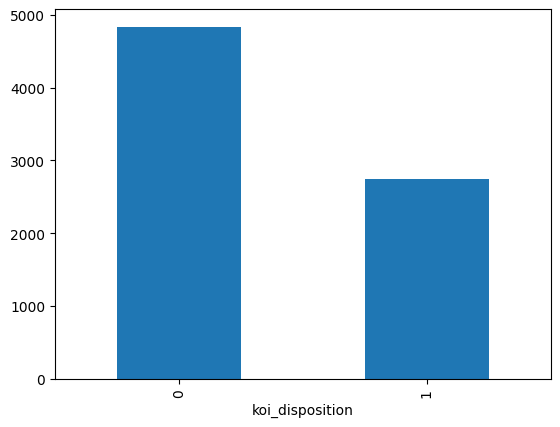

In [ ]:
exo['koi_disposition'].value_counts().plot(kind='bar')

The target variable exhibited a moderate class imbalance, with false positives representing approximately 64% of observations and confirmed exoplanets representing approximately 36%. Although the dataset was not perfectly balanced,


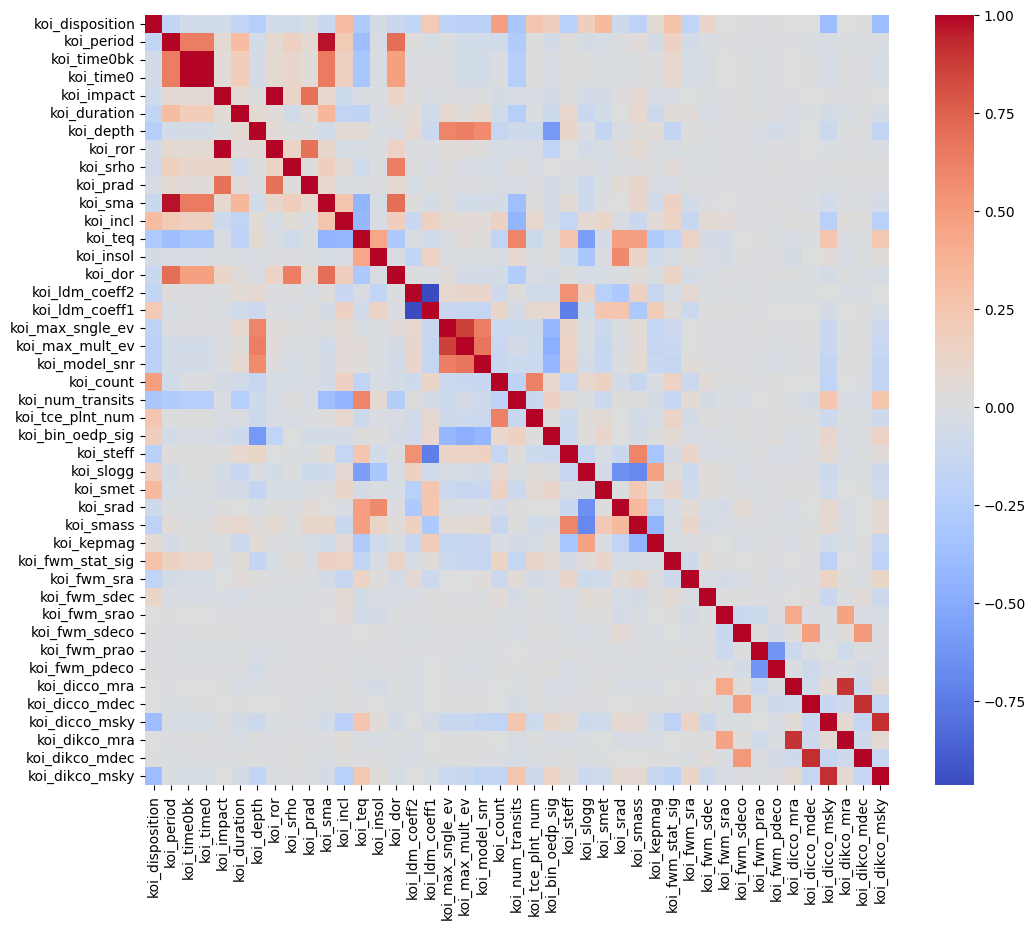

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(exo.corr(), cmap='coolwarm')
plt.show()

`Observations`

1. Most feature pairs show low correlation (values
close to 0), indicating that many variables provide independent information to the machine learning models.

2. A few groups of features exhibit moderate to strong positive correlations (shown in red), suggesting that they measure similar physical properties or are mathematically related.

3. Some feature pairs display negative correlations (shown in blue), indicating an inverse relationship between those variables.

4. No widespread multicollinearity was observed across the dataset, as only a limited number of feature pairs showed strong correlations.

`Strong positive correlations were observed among several measurement-related features (e.g., koi_max_sngle_ev and koi_max_mult_ev, as well as groups of koi_dicco_* and koi_dikco_* features), indicating that these variables capture closely related characteristics of the observed exoplanets.`

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(x_train, y_train)

LogisticRegression(max_iter=5000)

In [ ]:
y_pred = lr.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.932806324110672

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       962
           1       0.90      0.92      0.91       556

    accuracy                           0.93      1518
   macro avg       0.93      0.93      0.93      1518
weighted avg       0.93      0.93      0.93      1518



0 = FALSE POSITIVE
1 = CONFIRMED EXOPLANET

For the exoplanet dataset- **"logistic regression"** gives the metrics-

**Class 0 (False Positive)**:

`Precision = 0.95`

When the model says:

when the model identifies false positive-
it is correct 95% of the time.

`Recall = 0.94`

Out of all actual false positives, the model successfully identified 94% of them.

`F1 = 0.95`

A balanced score combining precision and recall.




**class 1(confirmed exoplanet):**

`Precision = 0.90`

model predicts exoplanet -
it is correct 90% of the time.

`Recall = 0.92`

Out of all real exoplanets in the test set, the model successfully found 92% of them.

`F1 = 0.91`

Balanced measure of exoplanet detection performance.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_rf)

0.97167325428195

In [ ]:
print(confusion_matrix(y_test, y_pred_rf))

[[947  15]
 [ 28 528]]


In [ ]:

print("Random forest")
print(classification_report(y_test, y_pred_rf))

Random forest
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       962
           1       0.97      0.95      0.96       556

    accuracy                           0.97      1518
   macro avg       0.97      0.97      0.97      1518
weighted avg       0.97      0.97      0.97      1518



0 = FALSE POSITIVE
1 = CONFIRMED EXOPLANET

For the exoplanet dataset- **"Random forest"** gives the metrics-

**Class 0 (False Positive)**:

`Precision = 0.97`

When the model says:

when the model identifies false positive-
it is correct 97% of the time.

`Recall = 0.98`

Out of all actual false positives, the model successfully identified 98% of them.

`F1 = 0.98`

A balanced score combining precision and recall.




**class 1(confirmed exoplanet):**

`Precision = 0.97`

model predicts exoplanet -
it is correct 97% of the time.

`Recall = 0.95`

Out of all real exoplanets in the test set, the model successfully found 95% of them.

`F1 = 0.96`

Balanced measure of exoplanet detection performance.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    random_state=42
)

hgb.fit(x_train, y_train)

y_pred_hgb = hgb.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_hgb)

0.9762845849802372

In [ ]:
print(confusion_matrix(y_test, y_pred_hgb))

[[941  21]
 [ 15 541]]


In [ ]:


print("HistGradientBoostingClassifier")
print(classification_report(y_test, y_pred_hgb))

HistGradientBoostingClassifier
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       962
           1       0.96      0.97      0.97       556

    accuracy                           0.98      1518
   macro avg       0.97      0.98      0.97      1518
weighted avg       0.98      0.98      0.98      1518



0 = FALSE POSITIVE
1 = CONFIRMED EXOPLANET

For the exoplanet dataset- **"Random forest"** gives the metrics-

**Class 0 (False Positive)**:

`Precision = 0.98`

When the model says:

when the model identifies false positive-
it is correct 98% of the time.

`Recall = 0.98`

Out of all actual false positives, the model successfully identified 98% of them.

`F1 = 0.98`

A balanced score combining precision and recall.




**class 1(confirmed exoplanet):**

`Precision = 0.96`

model predicts exoplanet -
it is correct 96% of the time.

`Recall = 0.97`

Out of all real exoplanets in the test set, the model successfully found 95% of them.

`F1 = 0.97`

Balanced measure of exoplanet detection performance.

In [ ]:
y_prob_lr = lr.predict_proba(x_test)[:,1]
y_prob_rf = rf.predict_proba(x_test)[:,1]
y_prob_hgb = hgb.predict_proba(x_test)[:,1]

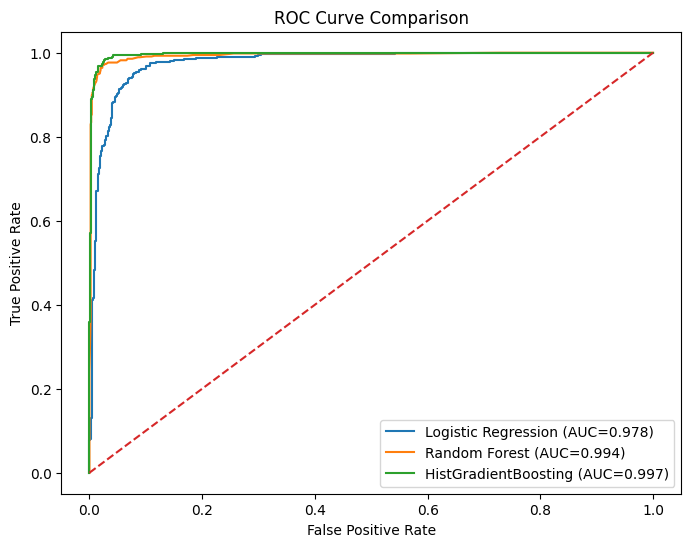

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_hgb, tpr_hgb, _ = roc_curve(y_test, y_prob_hgb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_hgb = auc(fpr_hgb, tpr_hgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC={auc_lr:.3f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC={auc_rf:.3f})')

plt.plot(fpr_hgb, tpr_hgb,
         label=f'HistGradientBoosting (AUC={auc_hgb:.3f})')

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

The ROC curve comparison showed that HistGradientBoosting achieved the highest Area Under the Curve (AUC = 0.997), followed by Random Forest (AUC = 0.994) and Logistic Regression (AUC = 0.978). The ROC curve of HistGradientBoosting remained closest to the upper-left corner of the graph, indicating superior discrimination between confirmed exoplanets and false positives across different classification thresholds.

Among the evaluated models, HistGradientBoostingClassifier achieved the best overall performance. It obtained the highest test accuracy of 97.6%, outperforming Logistic Regression (93%) and Random Forest (97.16%). Furthermore, ROC curve analysis showed that HistGradientBoosting achieved the highest Area Under the Curve (AUC = 0.997), indicating superior ability to distinguish confirmed exoplanets from false positives across a wide range of classification thresholds.

The improved performance can be attributed to the model's ability to capture complex nonlinear relationships present in the Kepler dataset. Unlike Logistic Regression, which assumes a linear decision boundary, HistGradientBoosting can learn intricate patterns between planetary and stellar features. Compared to Random Forest, the boosting approach sequentially improves upon previous errors, resulting in slightly better generalization and classification performance.

Based on the evaluation metrics and ROC analysis, HistGradientBoostingClassifier was selected as the final model for exoplanet classification.
